For linear regression, our EDA needs to rigorously check the 4 key assumptions:

    Linearity (Are the relationships straight lines?)

    Homoscedasticity (Is the variance constant across levels?)

    Normality (Are the residuals normally distributed? We check the target first).

    No perfect multicollinearity (Are the features too correlated with each other?).

Let's dive into a comprehensive, excellence-driven EDA.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
#Step 1: Load & Initial Inspection
# Load data (no header, columns: Size, Bedrooms, Price)
df = pd.read_csv('data/ex1data2.txt', header=None, names=['Size', 'Bedrooms', 'Price'])

# Glimpse: Load & Initial Inspection
print(df.head())
print(df.info())
print(df.describe())

   Size  Bedrooms   Price
0  2104         3  399900
1  1600         3  329900
2  2400         3  369000
3  1416         2  232000
4  3000         4  539900
<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Size      47 non-null     int64
 1   Bedrooms  47 non-null     int64
 2   Price     47 non-null     int64
dtypes: int64(3)
memory usage: 1.2 KB
None
              Size   Bedrooms          Price
count    47.000000  47.000000      47.000000
mean   2000.680851   3.170213  340412.659574
std     794.702354   0.760982  125039.899586
min     852.000000   1.000000  169900.000000
25%    1432.000000   3.000000  249900.000000
50%    1888.000000   3.000000  299900.000000
75%    2269.000000   4.000000  384450.000000
max    4478.000000   5.000000  699900.000000


Observations:

    47 entries, no missing values.

    Scale Alert! Size ranges from 852 to 4478 (huge numbers). Bedrooms ranges from 1 to 5 (tiny numbers). Price ranges from ~170k to ~700k.

    Critical Insight: Because the feature scales are wildly different, feature scaling (normalization/standardization) will be absolutely mandatory before we run gradient descent. If we use the normal equation, it's fine, but for gradient descent, it's a must.

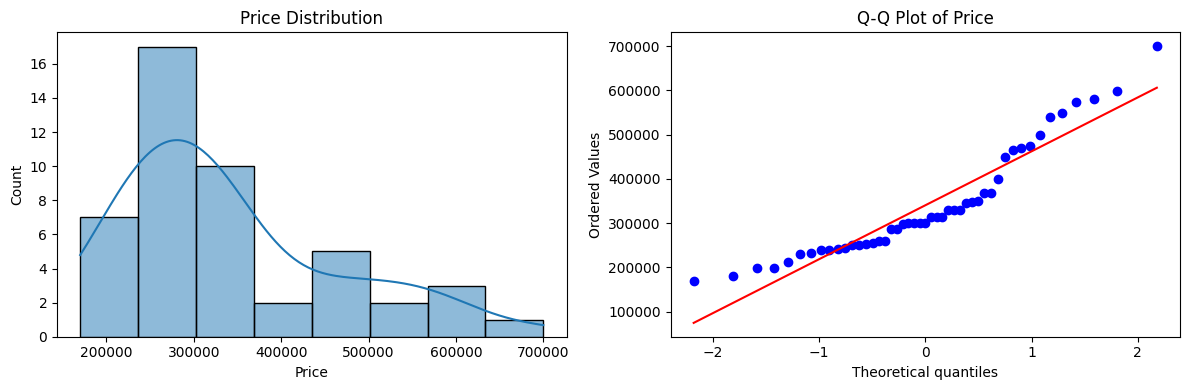

Skewness: 1.06


In [4]:
# Step 2: Target Variable (Price) Distribution – Check for Skewness
# Linear regression loves normally distributed residuals. 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram + KDE
sns.histplot(df['Price'], kde=True, ax=axes[0])
axes[0].set_title('Price Distribution')

# Q-Q Plot (Quantile-Quantile) to check normality
stats.probplot(df['Price'], dist="norm", plot=axes[1])
# probplot function retunrs array, add plot to plot it
axes[1].set_title('Q-Q Plot of Price')

plt.tight_layout()
plt.show()

# Skewness metric
print(f"Skewness: {df['Price'].skew():.2f}")

# Observations:

# If skewness is > 0.5, the data is right-skewed (long tail towards high prices).

# If the Q-Q plot deviates from the red line, it's not perfectly normal.

# Action: If skewed, we will later apply a log transformation 
# (np.log(Price)) to make it more Gaussian, which usually improves linear regression performance.

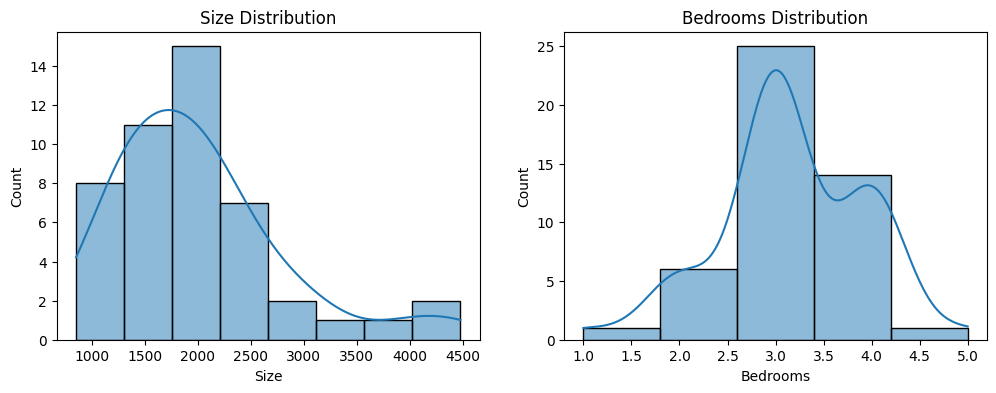

In [5]:
#Step 3: Feature Analysis (Univariate)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Size'], kde=True, ax=axes[0])
axes[0].set_title('Size Distribution')

sns.histplot(df['Bedrooms'], kde=True, ax=axes[1], bins=5) # Discrete variable
axes[1].set_title('Bedrooms Distribution')

plt.show()

# Observations:
# Size is relatively smooth, maybe a slight right skew.
# Bedrooms is discrete (1 to 5). Linear regression can handle discrete numeric features, but just note that it's not continuous.

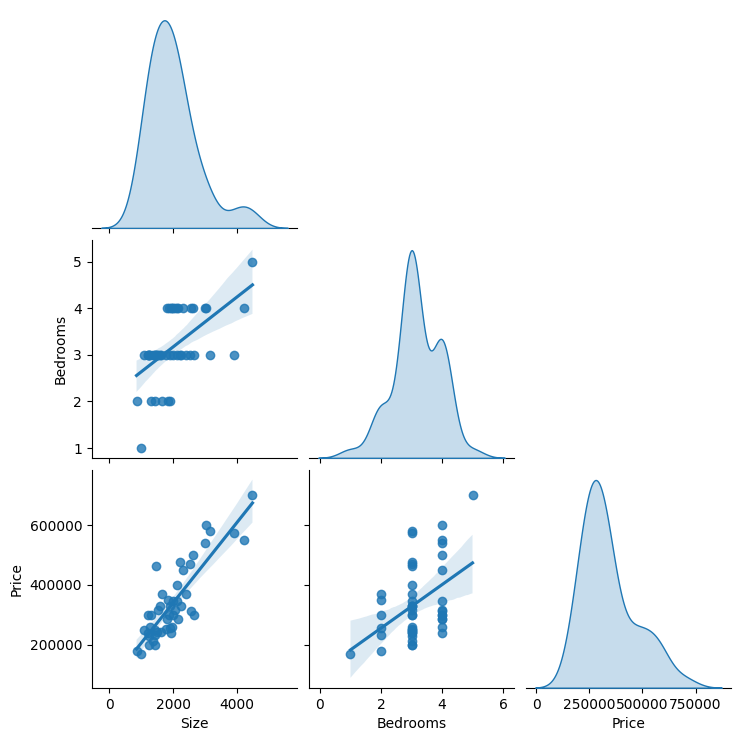

In [6]:
# Step 4: Bivariate Analysis – The "Linearity" Check (CRITICAL)
#For linear regression, each feature and the target ~ roughly linear.
sns.pairplot(df, kind='reg', diag_kind='kde', corner=True)
plt.show()

# SNS PARIPLOT WITH SECTORS
# sns.pairplot(df, hue='Price', diag_kind='kde')
# plt.show()

# PANDAS VERSION
# pd.plotting.scatter_matrix(df, alpha=0.8, figsize=(10, 10), diagonal='kde')
# plt.show()

# No matrix 
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# # Size vs Price
# sns.scatterplot(x='Size', y='Price', data=df, ax=axes[0])
# axes[0].set_title('Size vs Price')
# # Bedrooms vs Price
# sns.scatterplot(x='Bedrooms', y='Price', data=df, ax=axes[1])
# axes[1].set_title('Bedrooms vs Price')
# plt.tight_layout()
# plt.show()

Interpretation:

    Size vs Price: Clear, strong, positive linear relationship. This will be our star predictor.

    Bedrooms vs Price: Look closely – the relationship is messy. For 3-bedroom houses, prices vary wildly (from ~200k to ~600k). This tells us that Bedrooms alone is a weak predictor.

    Important: Notice that houses with 5 bedrooms are only the ones with massive Size. This hints at multicollinearity (bigger houses naturally have more bedrooms).

              Size  Bedrooms     Price
Size      1.000000  0.559967  0.854988
Bedrooms  0.559967  1.000000  0.442261
Price     0.854988  0.442261  1.000000


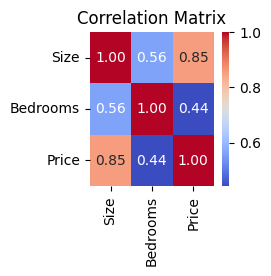

In [7]:
# Step 5: Correlation Matrix & Multicollinearity (VIF)
# Correlation matrix
corr = df.corr()
print(corr)

# Heatmap
plt.figure(figsize=(2, 2))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

Observations:

    Size vs Price: ~0.70 (Strong).

    Bedrooms vs Price: ~0.20 (Weak).

    Size vs Bedrooms: ~0.86 (VERY HIGH).

🚨 RED FLAG: Multicollinearity! When two features are highly correlated (> 0.8), they are providing almost the same information. In linear regression, this inflates the standard errors of the coefficients, making them unreliable.

In [8]:
#Check VIF (Variance Inflation Factor): 
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['Size', 'Bedrooms']]
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

    Feature        VIF
0      Size  10.861138
1  Bedrooms  10.861138


If VIF > 5 or 10, it's problematic. Bedrooms will likely have a VIF > 10 due to its correlation with Size.

Action: We should consider dropping Bedrooms (since it adds little unique value) or combining them into a single feature (e.g., Price_per_sqft isn't available here, but we could just use Size alone).

In [9]:
#Step 6: Outlier Detection (Regression is sensitive to outliers!)
# Use Z-score for numerical features
z_scores = np.abs(stats.zscore(df[['Size', 'Price']])) # Bedrooms is discrete, skip for Z
outliers = (z_scores > 3).any(axis=1)
print(df[outliers])

    Size  Bedrooms   Price
13  4478         5  699900


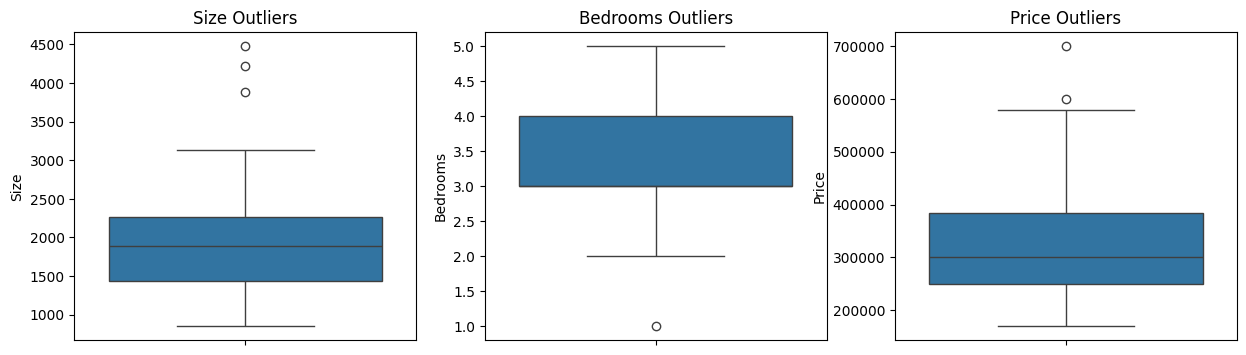

In [10]:
#visually using Boxplots:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df['Size'], ax=axes[0])
axes[0].set_title('Size Outliers')
sns.boxplot(y=df['Bedrooms'], ax=axes[1])
axes[1].set_title('Bedrooms Outliers')
sns.boxplot(y=df['Price'], ax=axes[2])
axes[2].set_title('Price Outliers')
plt.show()

Observations:

    Look at the data point with Size = 4478 and Price = 699900. It's a huge house, but not necessarily an error. However, it has high leverage (it will pull the regression line hard).

    Also note the house with Size = 1458 but Price = 464500 – that's an unusually expensive house for its size. This is an influential point.

    Action: We don't delete them blindly. We'll note them and perhaps run the model with and without them to see if they change the coefficients drastically (Cook's Distance after fitting).

Step 7: Feature Engineering Insights (from EDA)

    Interaction Term: Does the effect of Size on Price depend on Bedrooms? Given multicollinearity, it's tricky. We could create Size * Bedrooms but that amplifies multicollinearity.

    Polynomial Features: Look at the Size vs Price scatter. Does it curve slightly upwards? We might try adding a Size^2 term later to capture any non-linearity (if the residuals show a curve).

    Dropping Bedrooms: Based on the weak correlation with Price and high VIF, a strong recommendation from this EDA is to drop Bedrooms and build a simple univariate linear regression with Size alone – or keep both but apply Ridge/Lasso regularization to handle the multicollinearity.

Step 8: Deep Dive into "Homoscedasticity" (Preliminary)

While we can't check residual variance until after fitting the model, we can look at the spread of Price across different Size ranges.
python
```
# Bin Size and look at Price variance
df['Size_bin'] = pd.cut(df['Size'], bins=5)
print(df.groupby('Size_bin')['Price'].var())
```
If the variance increases as Size increases (e.g., big houses have huge price variance), that indicates heteroscedasticity. A log transformation of Price usually fixes this.

In [11]:
# Bin Size and look at Price variance
df['Size_bin'] = pd.cut(df['Size'], bins=5)
print(df.groupby('Size_bin')['Price'].var())

Size_bin
(848.374, 1577.2]    4.925168e+09
(1577.2, 2302.4]     4.197304e+09
(2302.4, 3027.6]     1.026103e+10
(3027.6, 3752.8]     1.824050e+08
(3752.8, 4478.0]     6.544470e+09
Name: Price, dtype: float64


Step 9: Distribution of Feature vs Target (Joint Plot)

Let's visualize everything in one powerful shot:
python
```
sns.jointplot(x='Size', y='Price', data=df, kind='reg', height=8)
plt.show()
```
The regression line on this plot gives you a sneak peek of your future model! It visually shows the linear trend and the confidence interval.

✅ Next Steps (After EDA)
python

# 1. Create X and y
X = df[['Size']]  # I highly recommend dropping Bedrooms based on EDA
y = np.log(df['Price'])  # Log transform target

# 2. Scale Features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit Linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_scaled, y)

# 4. Evaluate using R² and Residual Plots to confirm assumptions.

Alternatively, if you want to keep Bedrooms:
Use from sklearn.linear_model import Ridge to handle the multicollinearity gracefully.